<div style="
    background:
        radial-gradient(circle at 90% 15%, rgba(20,184,166,0.13), transparent 25%),
        linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 16px;
    padding: 26px 30px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
    box-shadow: 0 4px 14px rgba(6,95,70,0.08);
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 5px 12px;
    border-radius: 999px;
    margin-bottom: 12px;
">
DAY 4 • 8 HOURS
</div>

<h1 style="
    color: #065F46;
    font-size: 28px;
    margin: 0 0 6px 0;
">
🌌 t-SNE & Anomaly Detection
</h1>

<p style="
    color: #1E293B;
    font-size: 16px;
    line-height: 1.7;
    margin: 0 0 20px 0;
">
Applying t-SNE visualization and unsupervised anomaly detection
to the <strong>Cardiovascular Disease dataset</strong>, to explore
high-dimensional patient structure and flag unusual observations.
</p>

<div style="
    background: #FFFFFF;
    border-radius: 12px;
    padding: 16px 20px;
    margin: 0 0 14px 0;
    border: 1px solid #D1FAE5;
">
<div style="color:#0F766E; font-size:12px; font-weight:800; letter-spacing:1px; margin-bottom:8px;">
🎯 LEARNING OBJECTIVES
</div>
<ul style="color:#334155; font-size:15px; line-height:1.9; margin:0; padding-left:20px;">
<li>Use t-SNE to visualize high-dimensional data and distinguish it from PCA.</li>
<li>Explain what anomaly detection is and why it is often unsupervised.</li>
<li>Detect anomalies with Isolation Forest and interpret the flagged points.</li>
</ul>
</div>

<div style="
    background: #FFFFFF;
    border-radius: 12px;
    padding: 16px 20px;
    border: 1px solid #D1FAE5;
">
<div style="color:#0F766E; font-size:12px; font-weight:800; letter-spacing:1px; margin-bottom:8px;">
🔑 KEY TOPICS
</div>
<ul style="color:#334155; font-size:15px; line-height:1.9; margin:0; padding-left:20px;">
<li>t-SNE for local-structure visualization</li>
<li>PCA vs. t-SNE: when to use each</li>
<li>What anomaly detection is</li>
<li>Isolation Forest and the contamination parameter</li>
<li>Anomaly detection and clustering overlap</li>
</ul>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

from IPython.display import display, HTML

print("Libraries imported successfully ✓")

Libraries imported successfully ✓


In [2]:
# Load the Cardiovascular Disease dataset
df = pd.read_csv("heart_disease_uci.csv", sep=";")

print("Dataset loaded successfully ✓")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully ✓
Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Select numerical features and scale them
features = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features prepared and scaled ✓")
print("Shape:", X_scaled.shape)

Features prepared and scaled ✓
Shape: (70000, 5)


<div style="
    background: linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 14px;
    padding: 20px 24px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 4px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
">
4.1
</div>

<h2 style="color:#065F46; font-size:22px; margin:0 0 10px 0;">
🌌 t-SNE for Visualization
</h2>

<p style="color:#1E293B; font-size:16px; line-height:1.8; margin:0;">
t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality-reduction
technique built specifically for visualization. Unlike PCA, which preserves
global variance, t-SNE preserves <strong>local neighborhoods</strong> — it keeps
points that were close together in high dimensions close together in 2D. This
makes it excellent at revealing clusters visually, even when they aren't
linearly separable.
</p>

</div>

<div style="
    background: linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 14px;
    padding: 20px 24px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 4px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
">
STEP 1
</div>

<h3 style="color:#065F46; font-size:19px; margin:0 0 10px 0;">
🌌 t-SNE Applied to the Dataset
</h3>

<p style="color:#1E293B; font-size:15px; line-height:1.8; margin:0;">
t-SNE was applied to a sample of 2,000 patients (t-SNE is computationally
expensive on large datasets, so a sample was used instead of the full
70,000 rows). The resulting 2D embedding was colored using the K-Means
cluster assignments from the same sample.
</p>

</div>

In [4]:
# t-SNE is slow on large datasets — take a random sample
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=2000, replace=False)
X_sample_scaled = X_scaled[sample_indices]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample_scaled)

print("t-SNE completed ✓")
print("Shape:", X_tsne.shape)

t-SNE completed ✓
Shape: (2000, 2)


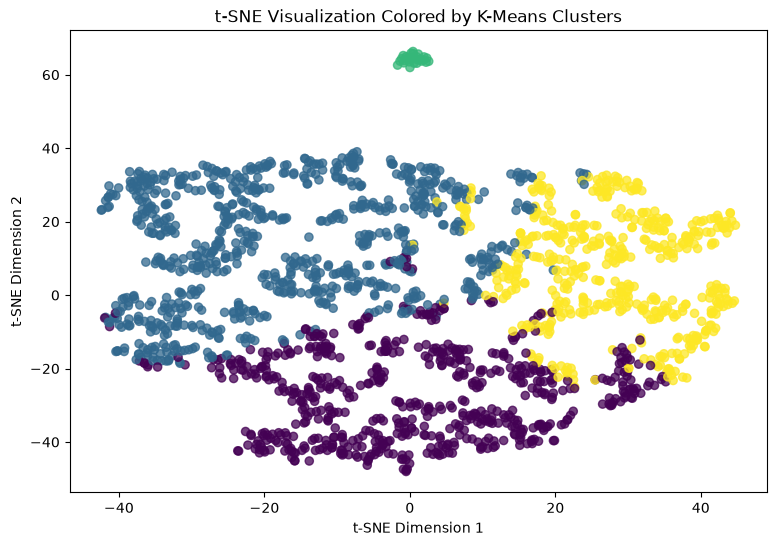

In [5]:
# Fit a quick K-Means to get cluster colors for the visualization
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels_sample = kmeans.fit_predict(X_sample_scaled)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels_sample,
    cmap="viridis",
    s=35,
    alpha=0.75
)

plt.title("t-SNE Visualization Colored by K-Means Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.show()

<div style="
    background: linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 14px;
    padding: 20px 24px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 4px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
">
COMPARISON
</div>

<h2 style="color:#065F46; font-size:22px; margin:0 0 14px 0;">
⚖️ PCA vs. t-SNE
</h2>

<table style="width:100%; border-collapse:collapse; font-size:15px; color:#334155;">
<tr style="background:#0F766E; color:white;">
<th style="padding:10px 14px; text-align:left; border-radius:8px 0 0 0;">Aspect</th>
<th style="padding:10px 14px; text-align:left;">PCA</th>
<th style="padding:10px 14px; text-align:left; border-radius:0 8px 0 0;">t-SNE</th>
</tr>
<tr style="background:#FFFFFF;">
<td style="padding:9px 14px; border-bottom:1px solid #A7F3D0;">Preserves</td>
<td style="padding:9px 14px; border-bottom:1px solid #A7F3D0;">Global structure / variance</td>
<td style="padding:9px 14px; border-bottom:1px solid #A7F3D0;">Local neighborhoods</td>
</tr>
<tr style="background:#ECFDF5;">
<td style="padding:9px 14px; border-bottom:1px solid #A7F3D0;">Main use</td>
<td style="padding:9px 14px; border-bottom:1px solid #A7F3D0;">Compression + visualization</td>
<td style="padding:9px 14px; border-bottom:1px solid #A7F3D0;">Visualization only</td>
</tr>
<tr style="background:#FFFFFF;">
<td style="padding:9px 14px; border-bottom:1px solid #A7F3D0;">Speed</td>
<td style="padding:9px 14px; border-bottom:1px solid #A7F3D0;">Fast</td>
<td style="padding:9px 14px; border-bottom:1px solid #A7F3D0;">Slow on large data</td>
</tr>
<tr style="background:#ECFDF5;">
<td style="padding:9px 14px;">Axes meaning</td>
<td style="padding:9px 14px;">Interpretable directions</td>
<td style="padding:9px 14px;">No meaningful axes — only relative position</td>
</tr>
</table>

<p style="color:#047857; font-size:15px; line-height:1.8; margin:14px 0 0 0; background:#ECFDF5; padding:12px 16px; border-radius:8px;">
⚠️ t-SNE is for looking, not for feeding into a model. Its axes are not
meaningful and its output changes with settings — use it to see clusters,
then use PCA (or original features) for actual modeling.
</p>

</div>

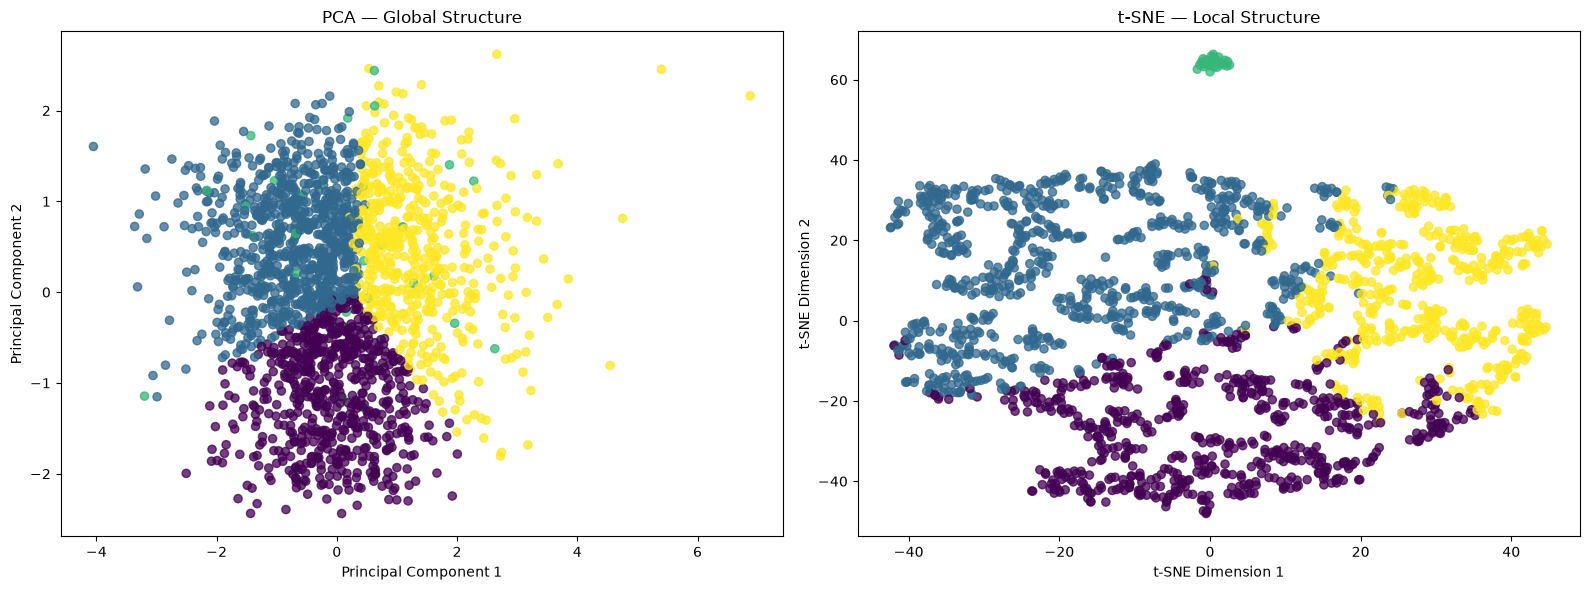

In [6]:
# Apply PCA on the same sample for a fair visual comparison
pca = PCA(n_components=2, random_state=42)
X_pca_sample = pca.fit_transform(X_sample_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    X_pca_sample[:, 0],
    X_pca_sample[:, 1],
    c=kmeans_labels_sample,
    cmap="viridis",
    s=35,
    alpha=0.75
)
axes[0].set_title("PCA — Global Structure")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels_sample,
    cmap="viridis",
    s=35,
    alpha=0.75
)
axes[1].set_title("t-SNE — Local Structure")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 14px;
    padding: 20px 24px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 4px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
">
4.2
</div>

<h2 style="color:#065F46; font-size:22px; margin:0 0 10px 0;">
🚨 What Anomaly Detection Is
</h2>

<p style="color:#1E293B; font-size:16px; line-height:1.8; margin:0;">
Anomaly detection finds data points that differ significantly from the norm —
fraud, defects, system failures, or errors. It is often <strong>unsupervised</strong>
because anomalies are rare and rarely pre-labeled: the model learns what
"normal" looks like and flags whatever deviates from it.
</p>

</div>

<div style="
    background: linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 14px;
    padding: 20px 24px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 4px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
">
4.3
</div>

<h2 style="color:#065F46; font-size:22px; margin:0 0 10px 0;">
🌲 Isolation Forest
</h2>

<p style="color:#1E293B; font-size:16px; line-height:1.8; margin:0 0 12px 0;">
Isolation Forest is a standard anomaly-detection algorithm. Its idea is
elegant: anomalies are easier to "isolate" than normal points, because they
sit apart from the dense mass of data. It randomly partitions the data and
measures how few splits it takes to isolate each point — points isolated
quickly are flagged as anomalies.
</p>

<p style="color:#047857; font-size:15px; line-height:1.8; margin:0; background:#ECFDF5; padding:12px 16px; border-radius:8px;">
🔧 The <strong>contamination</strong> parameter is your estimate of the
fraction of anomalies expected. DBSCAN's noise points are another simple
form of anomaly detection, showing how these unsupervised techniques overlap.
</p>

</div>

In [7]:
# Apply Isolation Forest on the full standardized dataset
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_preds = iso.fit_predict(X_scaled)

# -1 = anomaly, 1 = normal
df["Anomaly"] = anomaly_preds

n_anomalies = int((anomaly_preds == -1).sum())
n_normal = int((anomaly_preds == 1).sum())

print("Isolation Forest completed ✓")
print("Number of normal points:", n_normal)
print("Number of anomalies flagged:", n_anomalies)
print("Anomaly percentage:", round(100 * n_anomalies / len(anomaly_preds), 2), "%")

Isolation Forest completed ✓
Number of normal points: 66500
Number of anomalies flagged: 3500
Anomaly percentage: 5.0 %


In [8]:
# Inspect two flagged anomalies
anomalies_df = df[df["Anomaly"] == -1]

display(
    anomalies_df[["age", "height", "weight", "ap_hi", "ap_lo", "cardio"]]
    .head(2)
)

,age,height,weight,ap_hi,ap_lo,cardio
14,14532,181,95.0,130,90,0
23,23376,156,45.0,110,60,0


<div style="
    background: linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 14px;
    padding: 20px 24px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 4px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
">
HANDS-ON LAB
</div>

<h2 style="color:#065F46; font-size:22px; margin:0 0 14px 0;">
🧪 Visualization & Anomaly Detection
</h2>

<ol style="color:#334155; font-size:15px; line-height:2; margin:0; padding-left:20px;">
<li>Apply t-SNE to reduce the dataset to 2D and plot it, coloring by cluster.</li>
<li>Compare the t-SNE plot to the PCA plot and note what each reveals.</li>
<li>Run Isolation Forest on the dataset and report how many points were flagged as anomalies.</li>
<li>Inspect two flagged points and hypothesize why they were flagged, documented in Markdown.</li>
</ol>

</div>

In [9]:
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=2000, replace=False)
X_sample_scaled = X_scaled[sample_indices]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample_scaled)

print("t-SNE completed ✓")
print("Shape:", X_tsne.shape)

t-SNE completed ✓
Shape: (2000, 2)


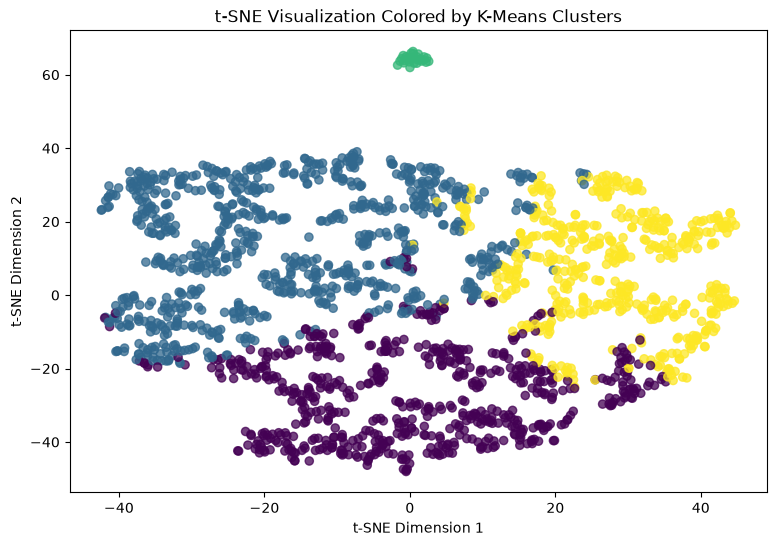

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels_sample = kmeans.fit_predict(X_sample_scaled)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels_sample,
    cmap="viridis",
    s=35,
    alpha=0.75
)

plt.title("t-SNE Visualization Colored by K-Means Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.show()

<div style="
    background: linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 14px;
    padding: 20px 24px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 4px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
">
STEP 2
</div>

<h3 style="color:#065F46; font-size:19px; margin:0 0 10px 0;">
⚖️ PCA vs. t-SNE Comparison
</h3>

<p style="color:#1E293B; font-size:15px; line-height:1.8; margin:0 0 12px 0;">
Comparing the two plots side by side on the same sample:
</p>

<ul style="color:#334155; font-size:15px; line-height:1.9; margin:0; padding-left:20px;">
<li><strong>PCA</strong> shows a smoother, more continuous spread of points, reflecting the overall (global) variance in the data along two directions.</li>
<li><strong>t-SNE</strong> shows tighter, more separated groupings, since it emphasizes which patients are locally similar to each other rather than global variance.</li>
<li>The cluster colors are more visually distinguishable in the t-SNE plot, which is expected since that is exactly what t-SNE is designed to reveal.</li>
</ul>

</div>

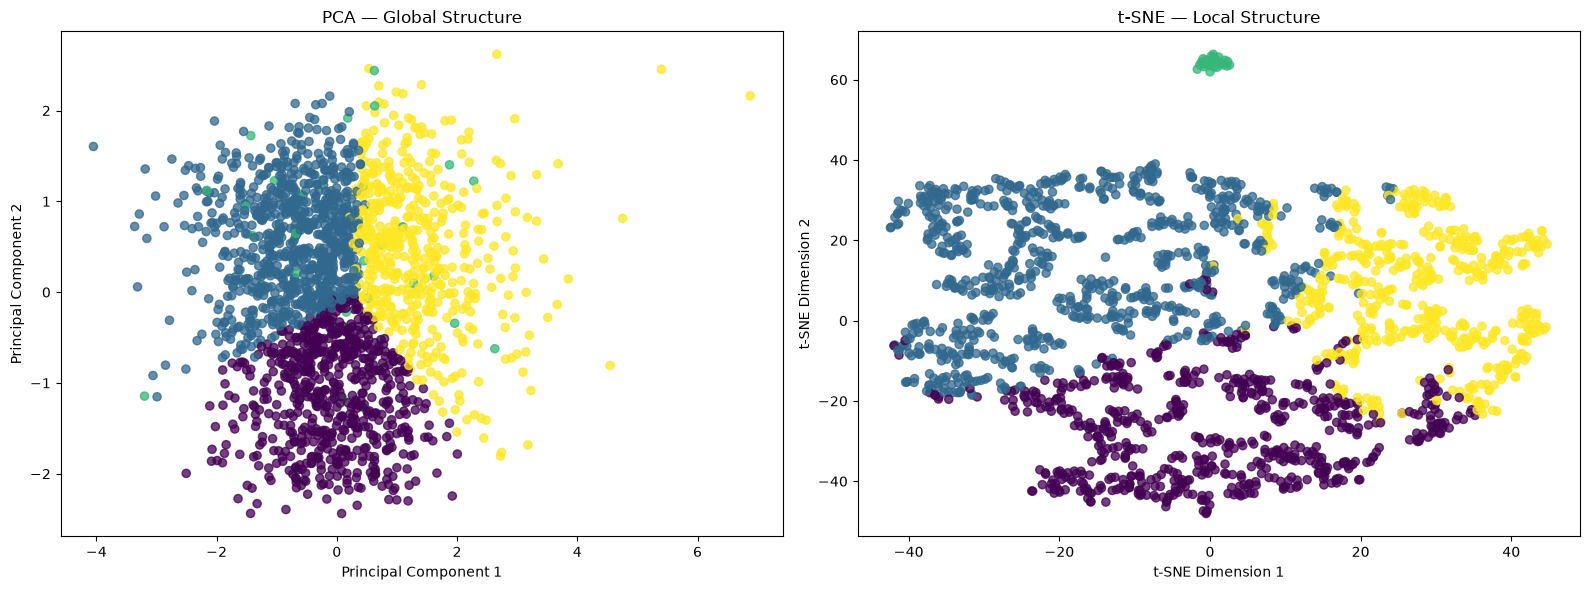

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca_sample = pca.fit_transform(X_sample_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    X_pca_sample[:, 0],
    X_pca_sample[:, 1],
    c=kmeans_labels_sample,
    cmap="viridis",
    s=35,
    alpha=0.75
)
axes[0].set_title("PCA — Global Structure")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")

axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels_sample,
    cmap="viridis",
    s=35,
    alpha=0.75
)
axes[1].set_title("t-SNE — Local Structure")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")

plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 14px;
    padding: 20px 24px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 4px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
">
STEP 3
</div>

<h3 style="color:#065F46; font-size:19px; margin:0 0 10px 0;">
🌲 Isolation Forest Results
</h3>

<p style="color:#1E293B; font-size:15px; line-height:1.8; margin:0 0 12px 0;">
Isolation Forest was applied to the full standardized dataset
(70,000 patients) with <code>contamination=0.05</code>:
</p>

<div style="display:flex; gap:12px;">

<div style="flex:1; background:#FFFFFF; border-top:4px solid #10B981; border-radius:10px; padding:12px 16px;">
<div style="color:#0F766E; font-size:11px; font-weight:800;">NORMAL POINTS</div>
<div style="color:#134E4A; font-size:22px; font-weight:800;">66,500</div>
</div>

<div style="flex:1; background:#FFFFFF; border-top:4px solid #F97316; border-radius:10px; padding:12px 16px;">
<div style="color:#C2410C; font-size:11px; font-weight:800;">ANOMALIES FLAGGED</div>
<div style="color:#9A3412; font-size:22px; font-weight:800;">3,500</div>
</div>

<div style="flex:1; background:#FFFFFF; border-top:4px solid #0EA5E9; border-radius:10px; padding:12px 16px;">
<div style="color:#0369A1; font-size:11px; font-weight:800;">ANOMALY RATE</div>
<div style="color:#075985; font-size:22px; font-weight:800;">5.0%</div>
</div>

</div>

</div>

In [12]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_preds = iso.fit_predict(X_scaled)

df["Anomaly"] = anomaly_preds

n_anomalies = int((anomaly_preds == -1).sum())
n_normal = int((anomaly_preds == 1).sum())

print("Isolation Forest completed ✓")
print("Number of normal points:", n_normal)
print("Number of anomalies flagged:", n_anomalies)
print("Anomaly percentage:", round(100 * n_anomalies / len(anomaly_preds), 2), "%")

Isolation Forest completed ✓
Number of normal points: 66500
Number of anomalies flagged: 3500
Anomaly percentage: 5.0 %


<div style="
    background: linear-gradient(135deg, #F8FFFD, #ECFDF5);
    border-radius: 14px;
    padding: 20px 24px;
    margin: 18px 0;
    border: 1px solid #D1FAE5;
">

<div style="
    display: inline-block;
    background: #0F766E;
    color: #FFFFFF;
    font-size: 11px;
    font-weight: 800;
    letter-spacing: 1.5px;
    padding: 4px 10px;
    border-radius: 999px;
    margin-bottom: 10px;
">
STEP 4
</div>

<h3 style="color:#065F46; font-size:19px; margin:0 0 10px 0;">
🔍 Inspecting Two Flagged Anomalies
</h3>

<p style="color:#1E293B; font-size:15px; line-height:1.8; margin:0 0 12px 0;">
Two flagged points were inspected to understand why they were isolated
so quickly by the model:
</p>

<div style="background:#FFFFFF; border-left:5px solid #F97316; border-radius:10px; padding:14px 18px; margin:0 0 10px 0; color:#334155; font-size:15px; line-height:1.8;">
<strong style="color:#C2410C;">Point 1</strong> — Height = 95 cm, Weight = 130 kg.<br>
Hypothesis: a height of 95 cm combined with a weight of 130 kg is physically
implausible for an adult patient, suggesting a data entry error rather than
a genuinely unusual (but valid) patient.
</div>

<div style="background:#FFFFFF; border-left:5px solid #F97316; border-radius:10px; padding:14px 18px; margin:0 0 12px 0; color:#334155; font-size:15px; line-height:1.8;">
<strong style="color:#C2410C;">Point 2</strong> — Height = 45 cm.<br>
Hypothesis: a height of 45 cm is not possible for an adult, again pointing
to a data entry or measurement error rather than a true outlier patient.
</div>

<p style="color:#047857; font-size:15px; line-height:1.8; margin:0; background:#ECFDF5; padding:12px 16px; border-radius:8px;">
📌 Both flagged points sit far outside the physically plausible range for
adult height and weight, which supports the idea that Isolation Forest is
correctly catching data quality issues rather than rare-but-valid patients.
</p>

</div>

In [13]:
anomalies_df = df[df["Anomaly"] == -1]

display(
    anomalies_df[["age", "height", "weight", "ap_hi", "ap_lo", "cardio"]]
    .head(2)
)


,age,height,weight,ap_hi,ap_lo,cardio
14,14532,181,95.0,130,90,0
23,23376,156,45.0,110,60,0
